In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('data/dataset_exercices.xlsx', sheet_name='commandes')

In [4]:
df.head()

,client_id,prenom,nom,age,pays,ville,statut,categorie,date_commande,quantite,prix_unitaire,total_achat,note_satisfaction
0,C1000,Laura,Bernard,33,France,Bordeaux,Standard,Alimentation,2023-02-22,9,47.95,431.55,4
1,C1001,Thomas,Martin,32,France,Toulouse,Standard,Électronique,2023-10-15,4,358.71,1434.84,5
2,C1002,Pierre,Simon,35,Maroc,Marrakech,Premium,Alimentation,2023-12-24,7,173.08,1211.56,2
3,C1003,Sophie,Rousseau,42,France,Lyon,Standard,Beauté,2023-06-26,10,135.67,1356.70,1
4,C1004,Maxime,Morel,42,Belgique,Bruxelles,Standard,Sport,2023-11-18,10,442.41,4424.10,3


In [5]:
df_french_touch = df[df['pays']=='France']

In [6]:
#1er essai brouillon
df[df['pays']=='France'].groupby('pays')['total_achat'].mean()

pays
France    1461.188043
Name: total_achat, dtype: float64

In [7]:
df_french_touch['total_achat'].mean()

1461.1880434782609

In [8]:
df.groupby('pays')['total_achat'].mean()

pays
Allemagne     855.424286
Belgique     1158.929286
Canada        995.995000
Espagne      1469.919091
France       1461.188043
Italie       1536.601250
Maroc        1848.822500
Suisse       1014.731000
Name: total_achat, dtype: float64

In [9]:
df['pays'].unique()

<ArrowStringArray>
[   'France',     'Maroc',  'Belgique', 'Allemagne',   'Espagne',    'Suisse',
    'Italie',    'Canada']
Length: 8, dtype: str

In [10]:
summary_df = df.groupby('pays').agg(
    sum_total_achat=('total_achat', 'sum'),
    avg_satisfaction=('note_satisfaction', 'mean')
).reset_index().round(2)

summary_df

,pays,sum_total_achat,avg_satisfaction
0,Allemagne,5987.97,2.43
1,Belgique,32450.02,3.21
2,Canada,5975.97,3.33
3,Espagne,48507.33,2.70
4,France,134429.30,2.90
5,Italie,12292.81,3.12
6,Maroc,29581.16,2.81
7,Suisse,10147.31,3.40


In [11]:
df.groupby('categorie')['total_achat'].sum().sort_values(ascending=False).head(3)
# ou df.groupby('categorie')['total_achat'].sum().nlargest(3)

categorie
Beauté          44166.81
Vêtements       41921.00
Électronique    39282.27
Name: total_achat, dtype: float64

In [12]:
df[df['statut'] == 'Premium'].groupby('pays')['total_achat'].mean().round(2)

pays
Belgique    1557.39
Canada       300.70
Espagne     1927.62
France      1491.66
Maroc       1546.84
Suisse      1175.42
Name: total_achat, dtype: float64

In [13]:
df['total_achat'].describe()

count     200.000000
mean     1396.859350
std      1096.476481
min        27.380000
25%       505.132500
50%      1151.390000
75%      1947.120000
max      4982.400000
Name: total_achat, dtype: float64

In [14]:
df.nlargest(5, 'total_achat')[['pays', 'categorie', 'total_achat']]

,pays,categorie,total_achat
29,Maroc,Électronique,4982.40
154,Belgique,Maison,4913.10
4,Belgique,Sport,4424.10
49,Maroc,Beauté,4076.10
106,Italie,Maison,3941.73


In [15]:
df['montant_tva'] = df['total_achat'] * 0.2
df.head()

,client_id,prenom,nom,age,pays,ville,statut,categorie,date_commande,quantite,prix_unitaire,total_achat,note_satisfaction,montant_tva
0,C1000,Laura,Bernard,33,France,Bordeaux,Standard,Alimentation,2023-02-22,9,47.95,431.55,4,86.310
1,C1001,Thomas,Martin,32,France,Toulouse,Standard,Électronique,2023-10-15,4,358.71,1434.84,5,286.968
2,C1002,Pierre,Simon,35,Maroc,Marrakech,Premium,Alimentation,2023-12-24,7,173.08,1211.56,2,242.312
3,C1003,Sophie,Rousseau,42,France,Lyon,Standard,Beauté,2023-06-26,10,135.67,1356.70,1,271.340
4,C1004,Maxime,Morel,42,Belgique,Bruxelles,Standard,Sport,2023-11-18,10,442.41,4424.10,3,884.820


In [16]:
import matplotlib.pyplot as plt

<Axes: xlabel='pays'>

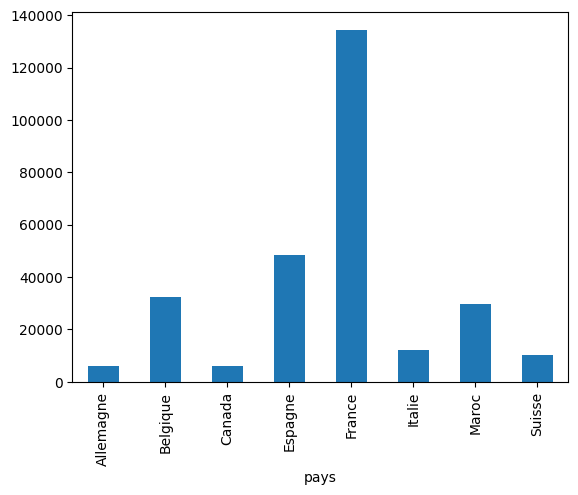

In [17]:
summary_df.plot(kind='bar', x='pays', y='sum_total_achat', legend=False)

In [18]:
df[['total_achat', 'note_satisfaction']].corr()

,total_achat,note_satisfaction
total_achat,1.0000,-0.0601
note_satisfaction,-0.0601,1.0000


In [19]:
df.select_dtypes(include="number").corr()["total_achat"].sort_values(ascending=False)

total_achat          1.000000
montant_tva          1.000000
prix_unitaire        0.737845
quantite             0.525575
note_satisfaction   -0.060100
age                 -0.062154
Name: total_achat, dtype: float64

<Axes: xlabel='total_achat', ylabel='note_satisfaction'>

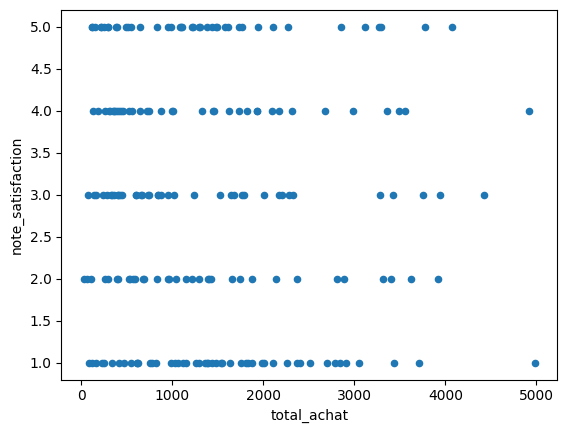

In [20]:
df.plot(kind='scatter', x='total_achat', y='note_satisfaction')

In [21]:
df.columns

Index(['client_id', 'prenom', 'nom', 'age', 'pays', 'ville', 'statut',
       'categorie', 'date_commande', 'quantite', 'prix_unitaire',
       'total_achat', 'note_satisfaction', 'montant_tva'],
      dtype='str')

In [22]:
df.groupby('pays')['date_commande'].count().nlargest(3)

pays
France      92
Espagne     33
Belgique    28
Name: date_commande, dtype: int64

In [23]:
df_big_three = ['France', 'Espagne', 'Belgique']
df_top_client = df.loc[df.pays.isin(df_big_three)]
df_top_client.groupby('pays')['total_achat'].idxmax()

pays
Belgique    154
Espagne     133
France       90
Name: total_achat, dtype: int64

In [24]:
# df_big_three = df.groupby('pays')['date_commande'].count().nlargest(3).index.tolist()
# df_filtered = df[df['pays'].isin(df_big_three)]
#
# result = df_filtered.loc[df_filtered.groupby('pays')['total_achat'].idxmax()][['pays', 'client_id']]
# result

In [25]:
df_top_client = df_top_client.loc[[90, 133, 154], ['pays', 'client_id']]
df_top_client

,pays,client_id
90,France,C1090
133,Espagne,C1133
154,Belgique,C1154


In [36]:
df[['categorie', 'statut']].drop_duplicates().sort_values(by='categorie')

,categorie,statut
0,Alimentation,Standard
2,Alimentation,Premium
40,Alimentation,VIP
3,Beauté,Standard
54,Beauté,Premium
60,Beauté,VIP
17,Jeux vidéo,Standard
50,Jeux vidéo,Premium
51,Jeux vidéo,VIP
7,Livres,Premium


In [ ]:
df.groupby(['categorie', 'statut'])['total_achat'].sum()

categorie     statut  
Alimentation  Premium      9547.28
              Standard    23811.51
              VIP           119.50
Beauté        Premium     11117.49
              Standard    25046.38
              VIP          8002.94
Jeux vidéo    Premium      4733.59
              Standard    24306.96
              VIP          2772.68
Livres        Premium      7469.67
              Standard    12325.40
Maison        Premium      8864.84
              Standard    22806.65
              VIP          2521.64
Sport         Premium     11669.39
              Standard    19138.76
              VIP          3913.92
Vêtements     Premium     14193.42
              Standard    25619.72
              VIP          2107.86
Électronique  Premium      3669.37
              Standard    26248.56
              VIP          9364.34
Name: total_achat, dtype: float64

In [41]:
sales = df[df.statut.isin(['Premium', 'Standard'])].groupby(['categorie', 'statut'])['total_achat'].sum()
sales / sales.groupby('categorie').transform('sum') * 100

categorie     statut  
Alimentation  Premium     28.619983
              Standard    71.380017
Beauté        Premium     30.741981
              Standard    69.258019
Jeux vidéo    Premium     16.299932
              Standard    83.700068
Livres        Premium     37.735002
              Standard    62.264998
Maison        Premium     27.989968
              Standard    72.010032
Sport         Premium     37.877607
              Standard    62.122393
Vêtements     Premium     35.650089
              Standard    64.349911
Électronique  Premium     12.264786
              Standard    87.735214
Name: total_achat, dtype: float64

In [52]:
df['month'] = df['date_commande'].dt.month

In [53]:
df.head(10)

,client_id,prenom,nom,age,pays,ville,statut,categorie,date_commande,quantite,prix_unitaire,total_achat,note_satisfaction,montant_tva,month
0,C1000,Laura,Bernard,33,France,Bordeaux,Standard,Alimentation,2023-02-22,9,47.95,431.55,4,86.310,2
1,C1001,Thomas,Martin,32,France,Toulouse,Standard,Électronique,2023-10-15,4,358.71,1434.84,5,286.968,10
2,C1002,Pierre,Simon,35,Maroc,Marrakech,Premium,Alimentation,2023-12-24,7,173.08,1211.56,2,242.312,12
3,C1003,Sophie,Rousseau,42,France,Lyon,Standard,Beauté,2023-06-26,10,135.67,1356.70,1,271.340,6
4,C1004,Maxime,Morel,42,Belgique,Bruxelles,Standard,Sport,2023-11-18,10,442.41,4424.10,3,884.820,11
5,C1005,Inès,Moreau,60,France,Paris,Standard,Sport,2023-02-10,4,433.04,1732.16,4,346.432,2
6,C1006,Marie,Morel,41,Allemagne,Berlin,Standard,Maison,2023-12-10,5,351.70,1758.50,1,351.700,12
7,C1007,Théo,Leclerc,28,Belgique,Liège,Premium,Livres,2023-05-19,9,113.49,1021.41,3,204.282,5
8,C1008,Manon,Dupont,69,Belgique,Bruxelles,Standard,Livres,2023-05-18,2,109.23,218.46,5,43.692,5
9,C1009,Sara,Rousseau,43,Belgique,Anvers,Premium,Alimentation,2023-05-16,3,126.83,380.49,5,76.098,5


In [79]:
df.groupby(['month','categorie'])['total_achat'].sum().groupby('month').idxmax().apply(lambda x: x[1])

month
1       Jeux vidéo
2     Alimentation
3           Beauté
4     Électronique
5     Alimentation
6     Alimentation
7     Électronique
8           Beauté
9           Maison
10           Sport
11           Sport
12       Vêtements
Name: total_achat, dtype: str

In [89]:
df['client_id'].unique()

<ArrowStringArray>
['C1000', 'C1001', 'C1002', 'C1003', 'C1004', 'C1005', 'C1006', 'C1007',
 'C1008', 'C1009',
 ...
 'C1190', 'C1191', 'C1192', 'C1193', 'C1194', 'C1195', 'C1196', 'C1197',
 'C1198', 'C1199']
Length: 200, dtype: str

In [ ]:
df.groupby('client_id').sum()